In [3]:
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

In [26]:
import torchvision.transforms.functional as F
from PIL import Image
import os
import pandas as pd
import matplotlib.pyplot as plt

input_data_path = r'C:\Users\songy\Downloads\UVA STAT 5630 Statistical Machine Learning\Project\data\chest_xray'
output_data_path = r'C:\Users\songy\Downloads\UVA STAT 5630 Statistical Machine Learning\Project\data\chest_xray_resized'

In [27]:
# create folders for storing resized images
try:
    os.makedirs(output_data_path, exist_ok=False)
except FileExistsError:
    pass

for dataset in ['train', 'test']:
    try:
        os.makedirs(os.path.join(output_data_path, dataset), exist_ok=False)
    except FileExistsError:
        pass
    for class_name in ['NORMAL', 'PNEUMONIA']:
        try:
            os.makedirs(os.path.join(output_data_path, dataset, class_name), exist_ok=False)
        except FileExistsError:
            pass

In [28]:
# identify all image files
image_data = []
for dataset in ['train', 'test']:
    for class_name in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(input_data_path, dataset, class_name)
        for img_file in os.listdir(folder):
            if img_file.endswith(('.jpeg')):
                image_data.append({'image_path': os.path.join(folder, img_file),
                'label': class_name,
                'sublabel': img_file.split(".")[0].split("-")[0],
                'dataset': dataset,
                'patient_id': img_file.split(".")[0].split("-")[1],
                'nth_img': img_file.split(".")[0].split("-")[2]
                })
df = pd.DataFrame(image_data)
sublabel_categories = ['NORMAL', 'BACTERIA', 'VIRUS']
df.sublabel = pd.Categorical(df.sublabel, categories=sublabel_categories, ordered=True)

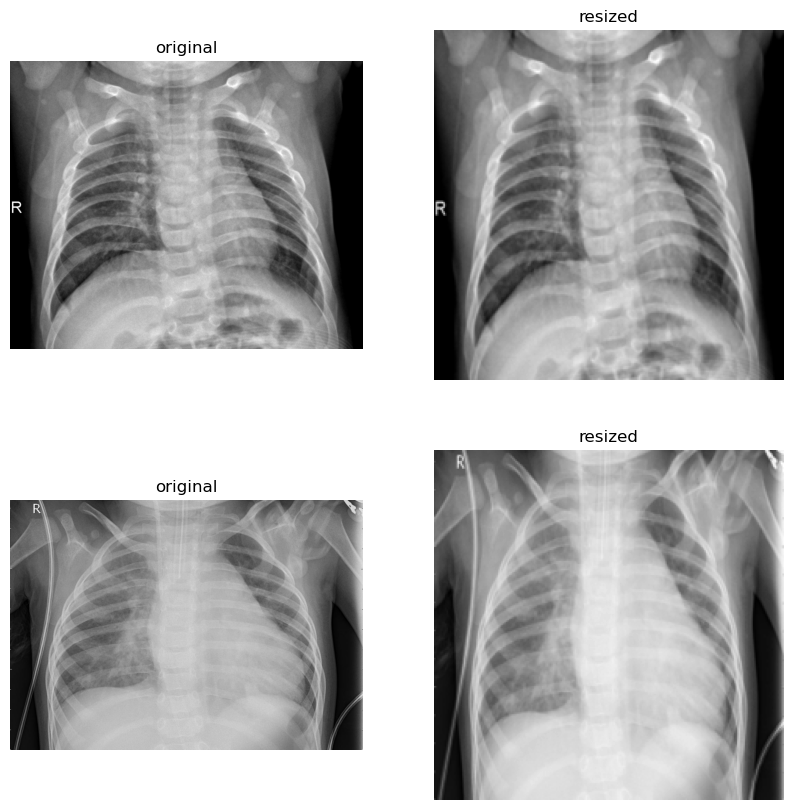

In [36]:
# Two examples of resizing
img1 = Image.open(df.image_path.iloc[2])
resized_img1 = F.resize(img1, size=(224, 224))
img2 = Image.open(df.image_path.iloc[2222])
resized_img2 = F.resize(img2, size=(224, 224))
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].imshow(img1, cmap ='gray'); axes[0,0].set_title("original"); axes[0,0].axis('off')
axes[0,1].imshow(resized_img1, cmap = 'gray'); axes[0,1].set_title("resized"); axes[0,1].axis('off')
axes[1,0].imshow(img2, cmap ='gray'); axes[1,0].set_title("original"); axes[1,0].axis('off')
axes[1,1].imshow(resized_img2, cmap = 'gray'); axes[1,1].set_title("resized"); axes[1,1].axis('off')
plt.show()

In [37]:
# Resize all images, then save them to disk
for j in range(df.shape[0]):
    input_image_path = df.image_path.iloc[j]
    output_image_path = input_image_path.replace("chest_xray", "chest_xray_resized")
    img = Image.open(input_image_path)
    resized_img = F.resize(img, size=(224, 224))
    resized_img.save(output_image_path)

In [46]:
# create a csv file which contains the file paths of all images, along with the corresponding information of each image
df['image_path'] = df.image_path.apply(lambda x: "/".join(x.split("\\")[x.split("\\").index("chest_xray"):]))
df['image_path'] = df.image_path.apply(lambda x: x.replace("chest_xray", "chest_xray_resized"))
df.to_csv(output_data_path + "/file_paths.csv", index=False)